# CORD-19 — Salute del catalogo `metadata.csv`

`metadata.csv` (568 MB, ~426k righe, 19 colonne) è l'**indice** che tiene insieme tutto: i campi
bibliografici (`title`, `authors`, `journal`, `publish_time`, `doi`, `url`, `license`…) **e** i
puntatori ai full-text (`pdf_json_files`, `pmc_json_files`). Sta sotto ogni task del progetto.

Domanda di questo notebook: **è sano?** Nello specifico —
1. quali colonne sono complete e quali quasi vuote/morte;
2. gli **identificatori** (`cord_uid`, `sha`, `pmcid`) sono unici e affidabili;
3. quanta **copertura full-text** abbiamo (quante righe hanno davvero un JSON associato);
4. com'è distribuito il corpus nel **tempo** e per **sorgente/licenza**.

Lo trattiamo con **Dask DataFrame** (stesso spirito distribuito del resto del progetto). A questa
taglia starebbe anche in pandas, ma teniamo la logica Dask — è quella che poi porti sul cluster.

## 1. Import + cluster locale

In [1]:
from pathlib import Path

import dask
import dask.dataframe as dd
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

print('dask', dask.__version__)

dask 2026.6.0


In [2]:
from dask.distributed import Client, LocalCluster

# chiudi un eventuale cluster precedente prima di crearne uno nuovo
try:
    client.close(); cluster.close()
except NameError:
    pass

cluster = LocalCluster(n_workers=4, threads_per_worker=2, memory_limit='4GB')
client = Client(cluster)
print('Dashboard:', client.dashboard_link)
client

Dashboard: http://127.0.0.1:8787/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:53117,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:53128,Total threads: 2
Dashboard: http://127.0.0.1:53129/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:53120,


2026-07-03 17:59:44,943 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle a3bdda006a53d05648868f4750713619 initialized by task ('shuffle-transfer-a3bdda006a53d05648868f4750713619', 1) executed on worker tcp://127.0.0.1:53128
2026-07-03 17:59:44,957 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle e6139068e00279c6febdc248e9cadb54 initialized by task ('shuffle-transfer-e6139068e00279c6febdc248e9cadb54', 1) executed on worker tcp://127.0.0.1:53128
2026-07-03 17:59:44,993 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 92a535d4f094b0a78e13a180748c5b7c initialized by task ('shuffle-transfer-92a535d4f094b0a78e13a180748c5b7c', 1) executed on worker tcp://127.0.0.1:53128
2026-07-03 17:59:45,159 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle a3bdda006a53d05648868f4750713619 deactivated due to stimulus 'task-finished-1783094385.157356'
2026-07-03 17:59:45,174 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 92a535d4f094b0a78e13a180748c5b7c

## 2. Caricamento (Dask, `dtype=str`)

`dtype=str` evita errori di type-inference su un CSV *sporco*. `blocksize='64MB'` dà 9 partizioni:
lo split a blocchi è delicato perché `abstract`/`title` contengono newline tra virgolette, ma qui
il conteggio righe combacia col totale ufficiale (425 796), quindi le partizioni sono sane.
Facciamo `persist()`: teniamo il CSV in memoria del cluster così le `compute()` successive volano.

In [3]:
DATA_DIR = Path('archive')
METADATA = DATA_DIR / 'metadata.csv'
assert METADATA.exists(), f'Non trovo {METADATA.resolve()}'

ddf = dd.read_csv(METADATA, dtype=str, blocksize='64MB')
ddf = ddf.persist()

n_rows = len(ddf)
print('righe      :', n_rows)
print('colonne    :', len(ddf.columns))
print('npartitions:', ddf.npartitions)
print('atteso (readme): 425796  -> match:', n_rows == 425796)
list(ddf.columns)

righe      : 425796
colonne    : 19
npartitions: 9
atteso (readme): 425796  -> match: True


['cord_uid',
 'sha',
 'source_x',
 'title',
 'doi',
 'pmcid',
 'pubmed_id',
 'license',
 'abstract',
 'publish_time',
 'authors',
 'journal',
 'mag_id',
 'who_covidence_id',
 'arxiv_id',
 'pdf_json_files',
 'pmc_json_files',
 'url',
 's2_id']

## 3. Valori mancanti per colonna

Prima domanda di salute: quanto è pieno ogni campo? Calcoliamo la % di null per colonna in modo
distribuito e la ordiniamo.

In [6]:
null_pct = (ddf.isnull().mean() * 100).compute().sort_values(ascending=False)
null_pct.round(2)

mag_id              100.00
arxiv_id             98.70
pmc_json_files       73.73
pdf_json_files       66.55
sha                  66.55
pmcid                64.99
who_covidence_id     59.94
pubmed_id            50.91
doi                  44.07
url                  39.68
abstract             27.92
s2_id                 9.20
journal               6.69
authors               4.46
title                 0.05
publish_time          0.05
license               0.00
source_x              0.00
cord_uid              0.00
dtype: float64

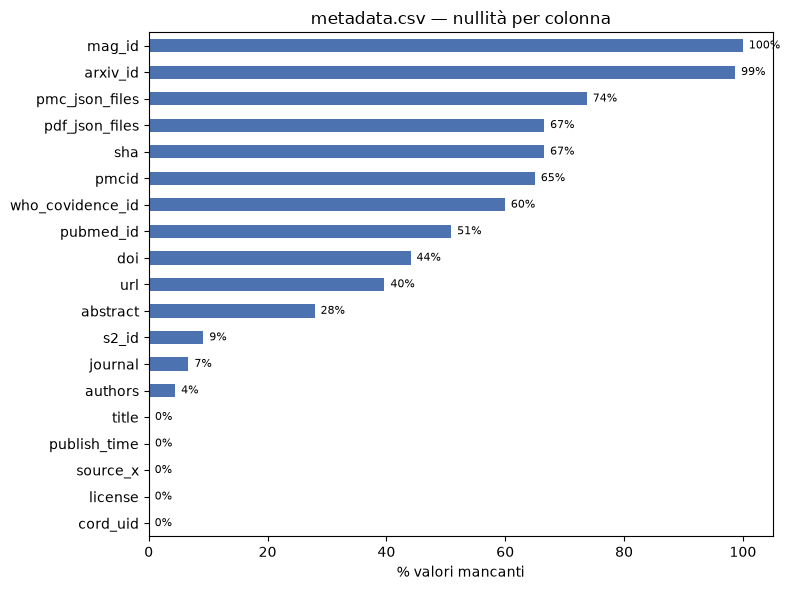

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
order = null_pct.sort_values()
order.plot.barh(ax=ax, color='#4C72B0')
ax.set_xlabel('% valori mancanti'); ax.set_xlim(0, 105)
ax.set_title('metadata.csv — nullità per colonna')
for i, v in enumerate(order):
    ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()

### Colonne complete vs morte

- **Sempre piene** (~0% null): `cord_uid`, `source_x`, `license`, e quasi `title`/`publish_time` (0.1%).
- **Molto buche**: `abstract` ~28% mancante, `doi` ~44%, `url` ~40%, `pubmed_id` ~51%, `who_covidence_id` ~60%.
- **Praticamente morte** (candidate al drop in preprocessing): **`mag_id` ~100% null**, **`arxiv_id` ~99%**.

Le colonne-puntatore `sha`/`pdf_json_files` (~66% null) e `pmcid`/`pmc_json_files` (~65–74% null)
non sono "malate": riflettono semplicemente che **molti paper non hanno full-text** (sezione 5).

## 4. Integrità degli identificatori

`cord_uid` dovrebbe essere la **chiave primaria** (un paper). Verifichiamolo, insieme a `sha` e `pmcid`.

In [8]:
ids = ['cord_uid', 'sha', 'pmcid']
counts  = dask.compute(*[ddf[c].count()   for c in ids])
uniques = dask.compute(*[ddf[c].nunique() for c in ids])
for c, cnt, nun in zip(ids, counts, uniques):
    print(f'{c:10s}  non-null={cnt:>7}  distinti={nun:>7}  duplicati={cnt - nun:>6}')

cord_uid    non-null= 425796  distinti= 406211  duplicati= 19585
sha         non-null= 142435  distinti= 142422  duplicati=    13
pmcid       non-null= 149071  distinti= 149071  duplicati=     0


### ⚠️ `cord_uid` NON è unico

Ci sono ~**19,6k** `cord_uid` duplicati: la stessa `cord_uid` compare su più righe (tipicamente
lo stesso lavoro raccolto da sorgenti diverse). Quindi `cord_uid` **non** è una primary key: per
qualsiasi statistica *per-paper* va fatto un `drop_duplicates(subset='cord_uid')`. `sha` e `pmcid`
sono invece sostanzialmente unici (pochi/zero duplicati).

## 5. Copertura full-text (il punto chiave)

Quante righe hanno davvero un JSON associato? È ciò che determina la dimensione reale dei Task
sul body-text. Una riga "ha PDF" se `pdf_json_files` è valorizzata, "ha PMC" se lo è `pmc_json_files`.

In [9]:
has_pdf = ddf['pdf_json_files'].notnull()
has_pmc = ddf['pmc_json_files'].notnull()

only_pdf, only_pmc, both, neither, multi_pdf = dask.compute(
    (has_pdf & ~has_pmc).sum(),
    (has_pmc & ~has_pdf).sum(),
    (has_pdf & has_pmc).sum(),
    (~has_pdf & ~has_pmc).sum(),
    ddf['pdf_json_files'].fillna('').str.contains(';').sum(),
)
either = only_pdf + only_pmc + both
print(f'solo PDF        : {only_pdf:>7}')
print(f'solo PMC        : {only_pmc:>7}')
print(f'entrambi        : {both:>7}')
print(f'almeno uno      : {either:>7}  ({100*either/n_rows:.0f}%)')
print(f'NESSUN full-text: {neither:>7}  ({100*neither/n_rows:.0f}%)')
print(f'righe multi-PDF (;) : {multi_pdf}')

solo PDF        :   36827
solo PMC        :    6228
entrambi        :  105608
almeno uno      :  148663  (35%)
NESSUN full-text:  277133  (65%)
righe multi-PDF (;) : 7716


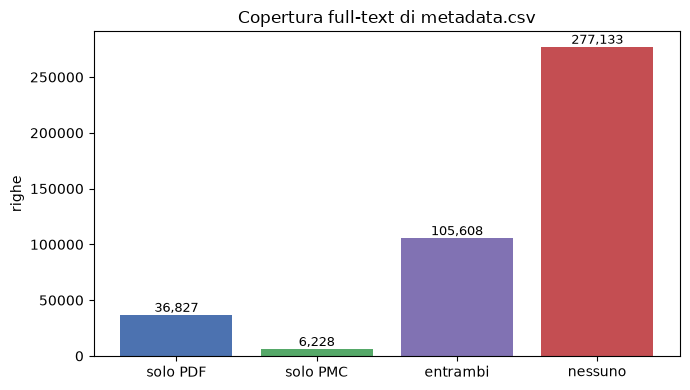

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = ['solo PDF', 'solo PMC', 'entrambi', 'nessuno']
vals   = [only_pdf, only_pmc, both, neither]
bars = ax.bar(labels, vals, color=['#4C72B0', '#55A868', '#8172B3', '#C44E52'])
ax.set_ylabel('righe'); ax.set_title('Copertura full-text di metadata.csv')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

**Lettura:** ~**65% delle righe non ha alcun full-text** — per quelle esistono solo i campi
bibliografici (titolo, abstract, autori…). I Task sul body-text (word count) girano quindi su
~149k paper, non su 426k. ~105k paper hanno **entrambe** le parse → doppio conteggio se leggi
le due cartelle insieme: dedup su `cord_uid`, preferendo la parse PMC. ~7,7k righe hanno più PDF
(`;`-separati). Per i titoli (Task 3/4) invece la copertura è totale: bastano i campi di questo CSV.

## 6. Distribuzione temporale (`publish_time`)

⚠️ Gotcha: `publish_time` ha **formati misti** (`YYYY-MM-DD` oppure solo `YYYY`); un
`pd.to_datetime` ingenuo scarterebbe ~metà dei valori. I primi 4 caratteri sono però sempre
l'anno: estraiamo quello.

In [11]:
year = dd.to_numeric(ddf['publish_time'].str.slice(0, 4), errors='coerce')
yc = year.value_counts().compute().sort_index()
yc = yc[(yc.index >= 1950) & (yc.index <= 2021)]
print('range anni:', int(yc.index.min()), '→', int(yc.index.max()))
print('anno di picco:', int(yc.idxmax()), '->', int(yc.max()), 'paper')
yc.tail(8)

range anni: 1950 → 2021
anno di picco: 2020 -> 319669 paper


publish_time
2014      6849
2015      7421
2016      7841
2017      7325
2018      7245
2019      8591
2020    319669
2021     11620
Name: count, dtype: Int64

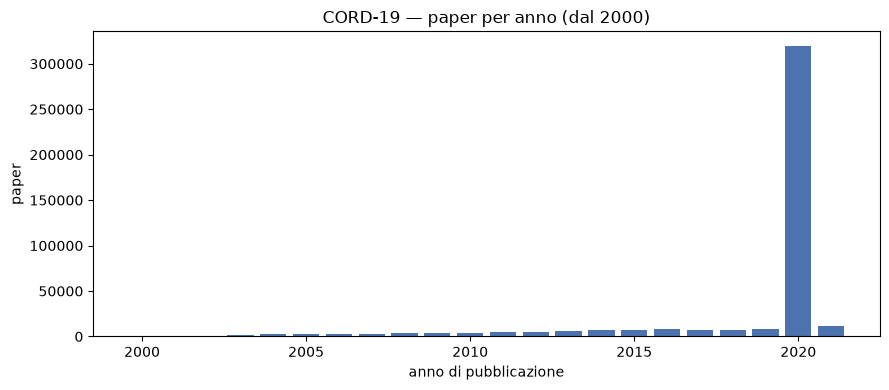

In [12]:
recent = yc[yc.index >= 2000]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(recent.index.astype(int), recent.values, color='#4C72B0')
ax.set_xlabel('anno di pubblicazione'); ax.set_ylabel('paper')
ax.set_title('CORD-19 — paper per anno (dal 2000)')
plt.tight_layout(); plt.show()

Come atteso il corpus **esplode nel 2020** (~320k paper, l'anno della pandemia); il resto è coda
storica. Utile come sanity-check: i dati coprono l'intervallo giusto e non ci sono anni assurdi.

## 7. Sorgenti e licenze

Da dove vengono i record e con che licenza — rilevante per capire eterogeneità e vincoli d'uso.

In [13]:
src = ddf['source_x'].value_counts().compute()
lic = ddf['license'].value_counts().compute()
print('--- source_x (top 8) ---')
print(src.head(8).to_string())
print('\n--- license (top 8) ---')
print(lic.head(8).to_string())

--- source_x (top 8) ---
source_x
BioRxiv; Medline; PMC                26
Medline                           88658
Medline; PMC; WHO                   928
Medline; WHO                        231
ArXiv; Elsevier                       3
ArXiv; Medline; PMC                 153
BioRxiv                            1099
BioRxiv; MedRxiv; Medline; PMC        4

--- license (top 8) ---
license
cc-by         45700
cc-by-nc       9029
cc-by-sa         33
gold-oa          57
unk          242823
hybrid-oa       141
no-cc         83049
bronze-oa       683


## 8. Verdetto di salute

Sintesi di cosa è sano, cosa manca e cosa tenere a mente prima di costruirci sopra l'analisi.

**✅ Sano**
- `cord_uid`, `source_x`, `license` sempre presenti; `title` e `publish_time` completi al 99,9%.
- Conteggio righe coerente col readme ufficiale (425 796); partizioni Dask integre.
- Copertura temporale sensata (picco 2020) e join verso i JSON ben definiti.

**⚠️ Da gestire**
- `cord_uid` **duplicato** (~19,6k righe): non è primary key → `drop_duplicates('cord_uid')` per
  le statistiche per-paper.
- **~65% righe senza full-text**; `abstract` mancante nel ~28%.
- `publish_time` a **formati misti** → estrai l'anno dai primi 4 caratteri (mai `to_datetime` ingenuo).
- Paper con doppia parse (~105k) e righe multi-PDF (~7,7k): rischio doppio conteggio → dedup.

**🗑️ Colonne morte** (droppabili in preprocessing): `mag_id` (~100% null), `arxiv_id` (~99%),
e molto rada `who_covidence_id` (~60%).

**🔗 Chiavi di join** (utili per legare al full-text — vedi `PMC_json_explore.ipynb`):
`sha` ↔ nome file in `pdf_json/`; `pmcid` ↔ `PMC<pmcid>.xml.json` in `pmc_json/`.

## 9. Chiusura

In [14]:
client.close()
cluster.close()